# Medical Insurance Charges Prediction

This project predicts individual medical insurance charges from features such as age, sex, BMI, number of children, smoking status and region. It covers data exploration, cleaning, encoding, model training with linear regression and evaluation.

Dataset: insurance.csv (Kaggle Medical Cost Personal Dataset).


## Import Libraries


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


## Load Dataset


In [2]:


# Load the dataset
df = pd.read_csv('insurance.csv')

# 1. Preview the first 5 rows
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## Exploratory Data Analysis


**Visualization 1: Smoking Status vs Insurance Charges**


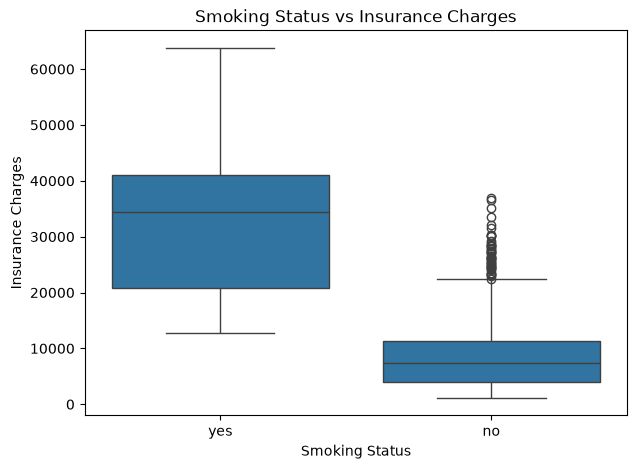

In [3]:
plt.figure(figsize=(7,5))

sns.boxplot(data=df, x="smoker", y="charges")

plt.title("Smoking Status vs Insurance Charges")
plt.xlabel("Smoking Status")
plt.ylabel("Insurance Charges")

plt.show()

In [4]:
# Check dataset quality before cleaning
# Before Preprocessing
print(df.head())
print(df.columns)
print(df.isnull().sum())
print("Duplicates:", df.duplicated().sum())

   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520
Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='str')
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64
Duplicates: 1


In [5]:
# 2. Dataset shape (rows, columns)
print("Shape:", df.shape)

Shape: (1338, 7)


In [6]:
# 3. Column names
print("Columns:", list(df.columns))

Columns: ['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']


In [7]:
# 4. Dataset info (data types, non-null counts)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 94.5 KB


In [8]:
# 5. Statistical summary
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [9]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(1)

## Data Cleaning and Preprocessing


In [11]:
# Remove duplicate rows
df = df.drop_duplicates()

In [12]:
# One hot encode categorical columns
df = pd.get_dummies(
    df,
    columns=["sex", "smoker", "region"]
)

In [13]:
df.columns

Index(['age', 'bmi', 'children', 'charges', 'sex_female', 'sex_male',
       'smoker_no', 'smoker_yes', 'region_northeast', 'region_northwest',
       'region_southeast', 'region_southwest'],
      dtype='str')

In [14]:
# After Preprocessing
print(df.head())
print(df.columns)
print(df.isnull().sum())
print("Duplicates:", df.duplicated().sum())

   age     bmi  children      charges  sex_female  sex_male  smoker_no  \
0   19  27.900         0  16884.92400        True     False      False   
1   18  33.770         1   1725.55230       False      True       True   
2   28  33.000         3   4449.46200       False      True       True   
3   33  22.705         0  21984.47061       False      True       True   
4   32  28.880         0   3866.85520       False      True       True   

   smoker_yes  region_northeast  region_northwest  region_southeast  \
0        True             False             False             False   
1       False             False             False              True   
2       False             False             False              True   
3       False             False              True             False   
4       False             False              True             False   

   region_southwest  
0              True  
1             False  
2             False  
3             False  
4             Fals

**Visualization 2: Age vs Insurance Charges**


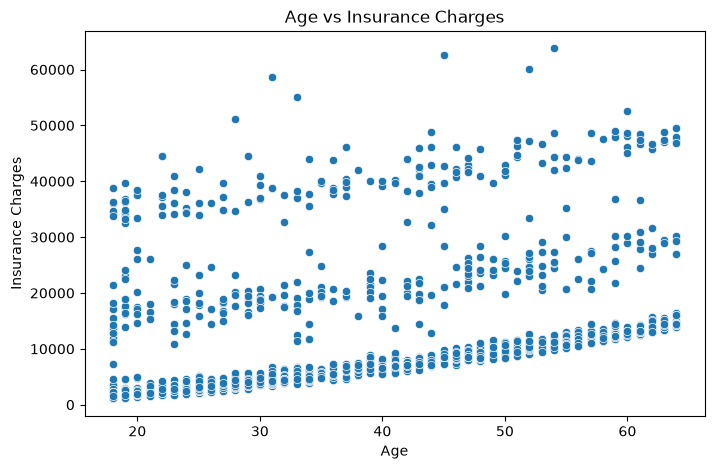

In [15]:
plt.figure(figsize=(8,5))

sns.scatterplot(data=df, x="age", y="charges")

plt.title("Age vs Insurance Charges")
plt.xlabel("Age")
plt.ylabel("Insurance Charges")

plt.show()

**Visualization 3: BMI vs Insurance Charges**

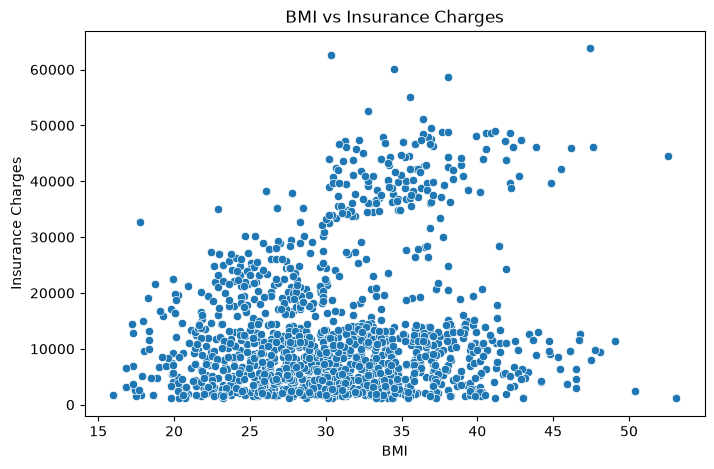

In [16]:
plt.figure(figsize=(8,5))

sns.scatterplot(data=df, x="bmi",y="charges")

plt.title("BMI vs Insurance Charges")

plt.xlabel("BMI")

plt.ylabel("Insurance Charges")

plt.show()


In [17]:
# Correlation between numeric features and charges
correlation = df[["age", "bmi", "children", "charges"]].corr()

print(correlation)

               age       bmi  children   charges
age       1.000000  0.109344  0.041536  0.298308
bmi       0.109344  1.000000  0.012755  0.198401
children  0.041536  0.012755  1.000000  0.067389
charges   0.298308  0.198401  0.067389  1.000000


**Visualization 4: Correlation Heatmap**


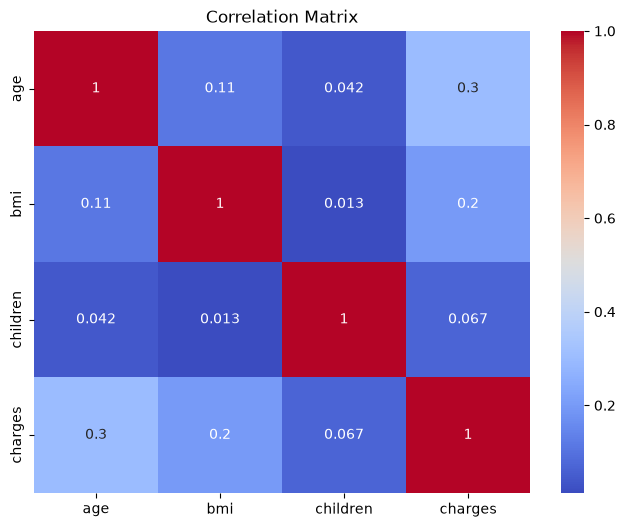

In [18]:
plt.figure(figsize=(8,6))

sns.heatmap(correlation, annot=True, cmap="coolwarm")

plt.title("Correlation Matrix")

plt.show()

## Model Building


In [19]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np


In [20]:
# Separate features and target variable
x = df.drop("charges", axis=1)
y = df["charges"]

print("X shape:", x.shape)
print("y shape:", y.shape)

print("\nFeatures:")
print(x.head())

print("\nTarget:")
print(y.head())

X shape: (1337, 11)
y shape: (1337,)

Features:
   age     bmi  children  sex_female  sex_male  smoker_no  smoker_yes  \
0   19  27.900         0        True     False      False        True   
1   18  33.770         1       False      True       True       False   
2   28  33.000         3       False      True       True       False   
3   33  22.705         0       False      True       True       False   
4   32  28.880         0       False      True       True       False   

   region_northeast  region_northwest  region_southeast  region_southwest  
0             False             False             False              True  
1             False             False              True             False  
2             False             False              True             False  
3             False              True             False             False  
4             False              True             False             False  

Target:
0    16884.92400
1     1725.55230
2     4449.462

In [21]:
# Split data into training and test sets
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

print("X_train:", x_train.shape)
print("X_test:", x_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (1069, 11)
X_test: (268, 11)
y_train: (1069,)
y_test: (268,)


In [22]:
# Creating a Model

model = LinearRegression()

# Training Model

model.fit(x_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [23]:
# Make predictions
y_pred = model.predict(x_test)

print("Sample predictions:")
print(y_pred[:5])

Sample predictions:
[ 8143.69388412  5737.11568259 14369.31487618 31745.51363586
  8962.38665706]


## Model Evaluation

In [24]:
# Compare actual vs predicted charges for the first 5 test samples
import pandas as pd

comparison = pd.DataFrame({
    "Actual Charges": y_test.iloc[:5].values,
    "Predicted Charges": y_pred[:5]
})

print(comparison)

   Actual Charges  Predicted Charges
0      8688.85885        8143.693884
1      5708.86700        5737.115683
2     11436.73815       14369.314876
3     38746.35510       31745.513636
4      4463.20510        8962.386657


In [25]:
# Calculate regression evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 4177.045561036322
MSE: 35478020.67523562
RMSE: 5956.342894363589
R2 Score: 0.8069287081198011


## Save the Trained Model


In [26]:
import pickle

with open("model.pkl", "wb") as file:
    pickle.dump(model, file)